In [1]:
import sys

custom_module_path = "/home/rebeccaz/Github/vampires_calibration"
if custom_module_path not in sys.path:
    sys.path.append(custom_module_path)

import instruments_jax as inst
import copy
import numpy as np
import json


# Step 1.a): Reading in csv - extracting single diffs and sums and configurations

In [2]:
file_path = "/home/rebeccaz/Github/vampires_calibration/data/20230914_processed_table.csv"
wavelength_string = "750-50"
obs_mode = "IPOL"

interleaved_values, interleaved_stds, configuration_list = inst.read_csv(file_path, 
    obs_mode = obs_mode, obs_filter = wavelength_string)
# print("Interleaved Values")
# print("Length: ", len(interleaved_values))
# print(interleaved_values)
# print("Interleaved Stds")
# print("Length: ", len(interleaved_stds))
# print(interleaved_stds[0 : 10])
# print("Configuration List")
# print("Length: ", len(configuration_list))
# print(configuration_list)
# print(interleaved_stds[0])

# Step 1.b) - Make plot of existing values as double diffs and sums

# Step 2: Creating a system Mueller matrix object

In [3]:
# This copied legacy cell used to load a 720 nm .npy start vector.
# The 750 nm fixed-EM IMR-offset fit starts from the JSON file in the next cell.

In [4]:
# Ideal start with HWP/IMR phi values from the broadband table
hwp_phi_waves = 0.479
imr_phi_waves = 0.479

theta_pol = 0

delta_HWP = 2 * np.pi * hwp_phi_waves
offset_HWP = 0

delta_derot = 2 * np.pi * imr_phi_waves

delta_opts = 0
epsilon_opts = 0
rot_opts = 0

delta_FLC = 2 * np.pi * 0.5
rot_FLC = 0

dichroic_phi = 0
dichroic_epsilon = 0
dichroic_theta = 0

em_gain = 1.0  # Fixed ideal EM gain

past_fit = {
    "dichroic": {"phi": dichroic_phi, "epsilon": dichroic_epsilon, "theta": dichroic_theta},
    "flc": {"phi": delta_FLC, "delta_theta": rot_FLC},
    "optics": {"phi": delta_opts, "epsilon": epsilon_opts, "theta": rot_opts},
    "image_rotator": {"phi": delta_derot},
    "hwp": {"phi": delta_HWP, "delta_theta": offset_HWP},
    "lp": {"theta": theta_pol},
}

print("Ideal table start for 750 nm")
print("HWP phi waves:", hwp_phi_waves)
print("IMR phi waves:", imr_phi_waves)
print("Past Fit: ", past_fit)

# NOTE: Components must be listed downstream to upstream
# Define the instrument configuration as a system dictionary
system_dict = {
    "components": {
        "wollaston": {
            "type": "wollaston_prism_function",
            "properties": {"beam": "o", "transmission_ratio": em_gain},
        },
        "dichroic": {
            "type": "diattenuator_retarder_function",
            "properties": {"phi": dichroic_phi, "epsilon": dichroic_epsilon, "theta": dichroic_theta},
        },
        "flc": {
            "type": "general_retarder_function",
            "properties": {"phi": delta_FLC, "theta": 0, "delta_theta": rot_FLC},
        },
        "optics": {
            "type": "diattenuator_retarder_function",
            "properties": {"phi": delta_opts, "epsilon": epsilon_opts, "theta": rot_opts},
        },
        "image_rotator": {
            "type": "general_retarder_function",
            "properties": {"phi": delta_derot, "theta": 0, "delta_theta": 0},
        },
        "hwp": {
            "type": "general_retarder_function",
            "properties": {"phi": delta_HWP, "theta": 0, "delta_theta": offset_HWP},
        },
        "lp": {
            "type": "general_linear_polarizer_function_with_theta",
            "properties": {"theta": theta_pol},
        },
    }
}

print(system_dict)


Ideal table start for 750 nm
HWP phi waves: 0.479
IMR phi waves: 0.479
Past Fit:  {'dichroic': {'phi': 0, 'epsilon': 0, 'theta': 0}, 'flc': {'phi': 3.141592653589793, 'delta_theta': 0}, 'optics': {'phi': 0, 'epsilon': 0, 'theta': 0}, 'image_rotator': {'phi': 3.0096457621390216}, 'hwp': {'phi': 3.0096457621390216, 'delta_theta': 0}, 'lp': {'theta': 0}}
{'components': {'wollaston': {'type': 'wollaston_prism_function', 'properties': {'beam': 'o', 'transmission_ratio': 1.0}}, 'dichroic': {'type': 'diattenuator_retarder_function', 'properties': {'phi': 0, 'epsilon': 0, 'theta': 0}}, 'flc': {'type': 'general_retarder_function', 'properties': {'phi': 3.141592653589793, 'theta': 0, 'delta_theta': 0}}, 'optics': {'type': 'diattenuator_retarder_function', 'properties': {'phi': 0, 'epsilon': 0, 'theta': 0}}, 'image_rotator': {'type': 'general_retarder_function', 'properties': {'phi': 3.0096457621390216, 'theta': 0, 'delta_theta': 0}}, 'hwp': {'type': 'general_retarder_function', 'properties': {'p

In [5]:
# Converting system dictionary into system Mueller Matrix object

system_mm = inst.generate_system_mueller_matrix(system_dict)
print(system_mm.evaluate())

[[0.5 0.5 0.  0. ]
 [0.5 0.5 0.  0. ]
 [0.  0.  0.  0. ]
 [0.  0.  0.  0. ]]


# Step 4: Creating a dictionary of p0 starting guesses

{'dichroic': {'phi': 0, 'epsilon': 0, 'theta': 0}, 'flc': {'phi': 3.141592653589793, 'delta_theta': 0}, 'optics': {'phi': 0, 'epsilon': 0, 'theta': 0}, 'image_rotator': {'phi': 3.0096457621390216}, 'hwp': {'phi': 3.0096457621390216, 'delta_theta': 0}, 'lp': {'theta': 0}}
logl value: 7727.495535157781


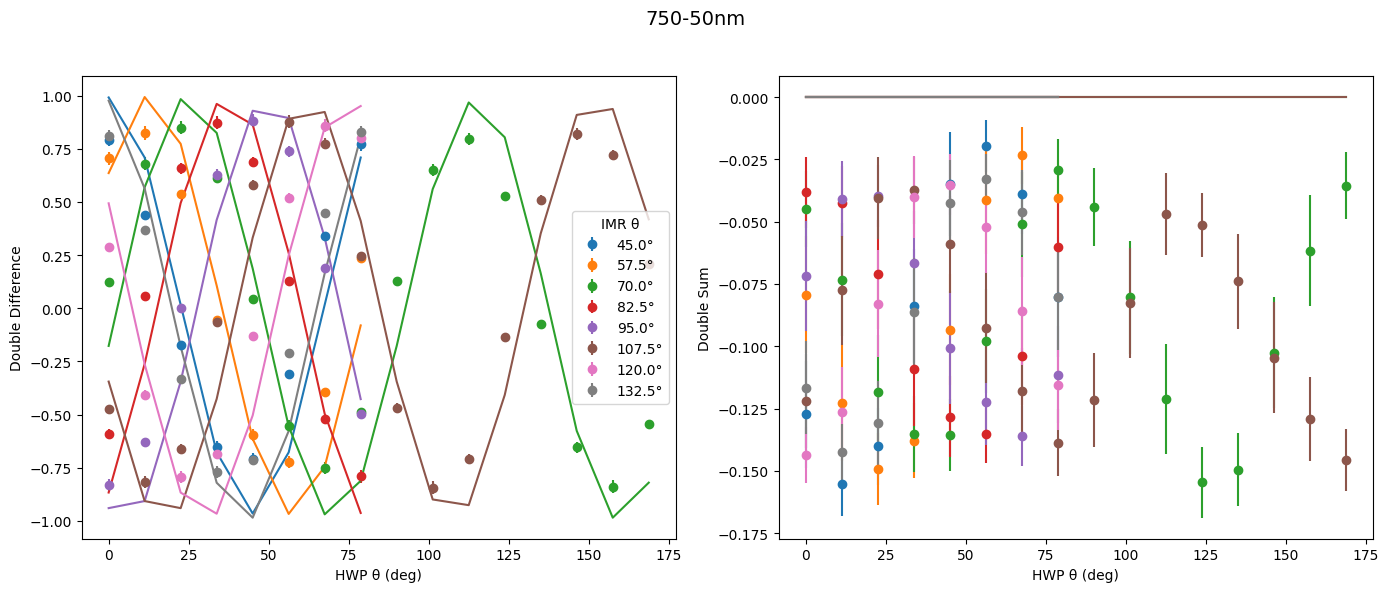

In [6]:
# Fitting all non-EM-gain parameters
p0 = copy.deepcopy(past_fit)
p0.pop("wollaston", None)
p0.setdefault("image_rotator", {}).pop("delta_theta", None)

print(p0)

p0_values, p0_keywords = inst.parse_configuration(p0)
s_in = np.array([1, 0, 0, 0])
logl_value = inst.logl(p0_values, p0_keywords, system_mm, interleaved_values, interleaved_stds, configuration_list,
    s_in=s_in, logl_function=None, process_dataset=inst.process_dataset, process_errors=inst.process_errors, 
    process_model=inst.process_model)
print("logl value: " + str(logl_value))

# TODO: Add an initial plot block here
# Plotting initial plot
updated_system_mm = inst.update_system_mm(p0_values, p0_keywords, system_mm)
model = inst.model(p0_values, p0_keywords, system_mm, configuration_list, 
    process_model = inst.process_model)

inst.plot_data_and_model(interleaved_values, interleaved_stds, model, 
    configuration_list, wavelength = wavelength_string)


# Step 5: Running minimize_system_Mueller_matrix iteratively

Before p0: {'dichroic': {'phi': 0, 'epsilon': 0, 'theta': 0}, 'flc': {'phi': 3.141592653589793, 'delta_theta': 0}, 'optics': {'phi': 0, 'epsilon': 0, 'theta': 0}, 'image_rotator': {'phi': 3.0096457621390216}, 'hwp': {'phi': 3.0096457621390216, 'delta_theta': 0}, 'lp': {'theta': 0}}
Iteration #: 1
logl_value: 1207.3646959502141
Best Fit Parameters: [-2.44612758e-01  9.13733200e-02  8.98769194e+00  3.15964524e+00
 -5.29931967e-01  7.44751712e-01  2.50497673e-04 -6.33357622e-01
  2.70868119e+00  3.31061034e+00  1.57373713e+00 -4.99023136e+00]


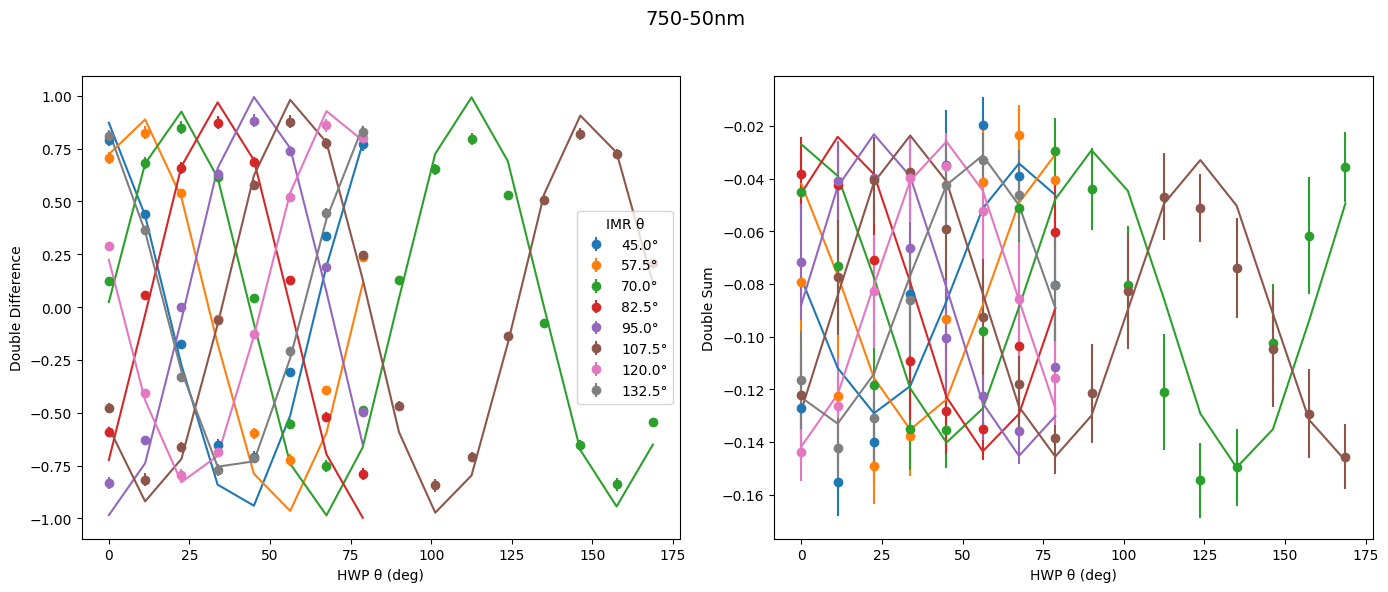

After p0: {'dichroic': {'phi': -0.2446127583517752, 'epsilon': 0.09137332000941317, 'theta': 8.987691935362811}, 'flc': {'phi': 3.159645239901259, 'delta_theta': -0.529931966905943}, 'optics': {'phi': 0.744751712009597, 'epsilon': 0.00025049767322456477, 'theta': -0.6333576215752208}, 'image_rotator': {'phi': 2.708681185925119}, 'hwp': {'phi': 3.310610338352923, 'delta_theta': 1.573737129844055}, 'lp': {'theta': -4.990231355070314}}
Before p0: {'dichroic': {'phi': -0.2446127583517752, 'epsilon': 0.09137332000941317, 'theta': 8.987691935362811}, 'flc': {'phi': 3.159645239901259, 'delta_theta': -0.529931966905943}, 'optics': {'phi': 0.744751712009597, 'epsilon': 0.00025049767322456477, 'theta': -0.6333576215752208}, 'image_rotator': {'phi': 2.708681185925119}, 'hwp': {'phi': 3.310610338352923, 'delta_theta': 1.573737129844055}, 'lp': {'theta': -4.990231355070314}}
Iteration #: 2
logl_value: 313.12043225573024
Best Fit Parameters: [-7.96807120e-02  4.53539925e-01  3.92729255e+01  3.163988

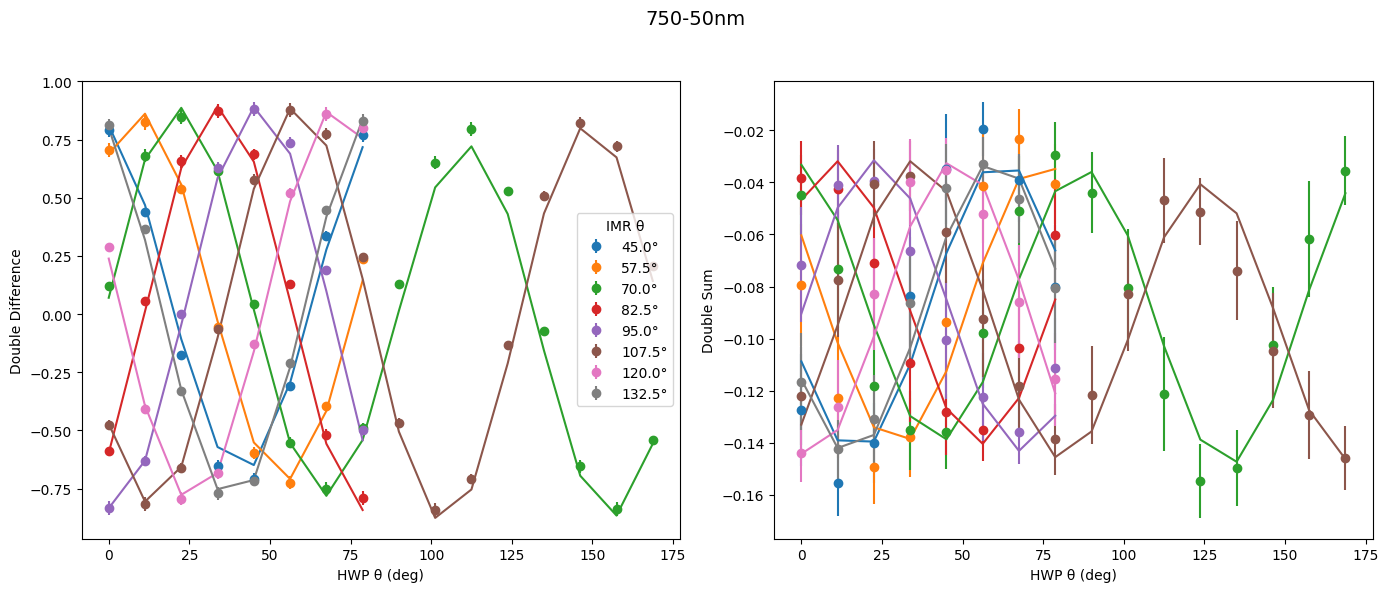

After p0: {'dichroic': {'phi': -0.07968071199364277, 'epsilon': 0.4535399252604855, 'theta': 39.27292553885151}, 'flc': {'phi': 3.163988480294254, 'delta_theta': 3.1348564683305105}, 'optics': {'phi': 1.731956893110194, 'epsilon': 0.0050518936152167465, 'theta': -3.280329644402097}, 'image_rotator': {'phi': 3.0134044546906154}, 'hwp': {'phi': 2.852195379044894, 'delta_theta': 3.7635483026273766}, 'lp': {'theta': -5.0}}
Before p0: {'dichroic': {'phi': -0.07968071199364277, 'epsilon': 0.4535399252604855, 'theta': 39.27292553885151}, 'flc': {'phi': 3.163988480294254, 'delta_theta': 3.1348564683305105}, 'optics': {'phi': 1.731956893110194, 'epsilon': 0.0050518936152167465, 'theta': -3.280329644402097}, 'image_rotator': {'phi': 3.0134044546906154}, 'hwp': {'phi': 2.852195379044894, 'delta_theta': 3.7635483026273766}, 'lp': {'theta': -5.0}}
Iteration #: 3
logl_value: 184.39025168701414
Best Fit Parameters: [-3.81506043e-01  1.56996581e-01  2.74674096e+01  3.67171570e+00
  4.95082765e+00  9.0

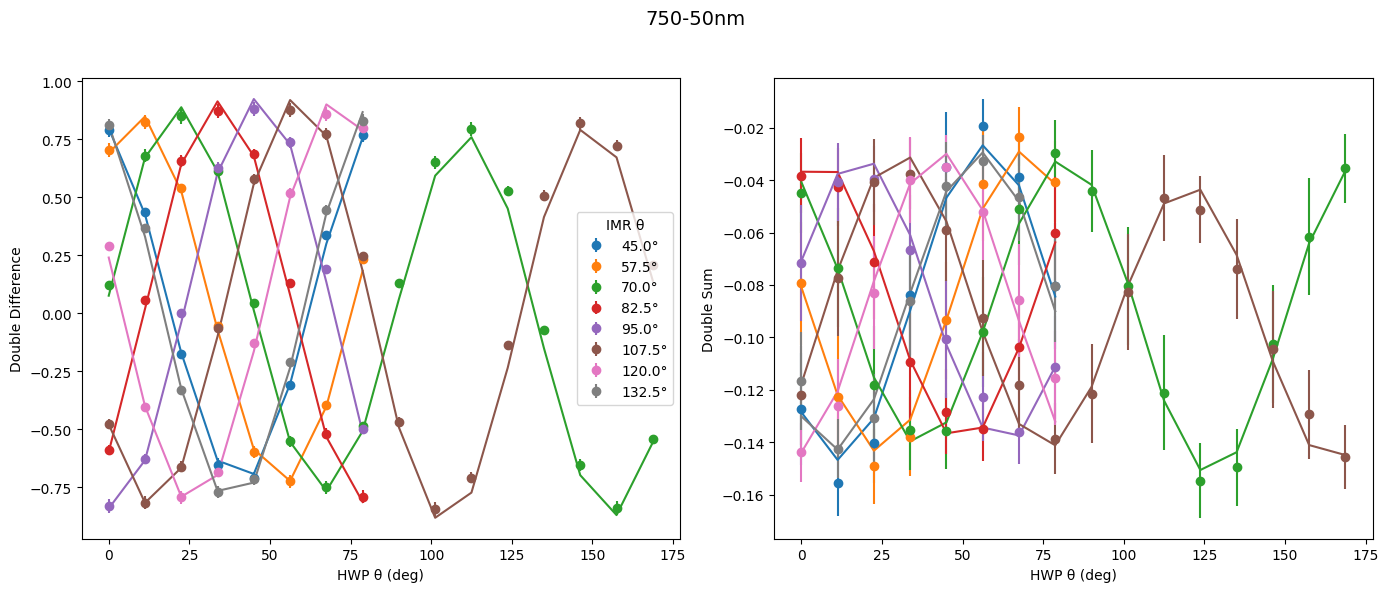

After p0: {'dichroic': {'phi': -0.38150604310197656, 'epsilon': 0.15699658069634032, 'theta': 27.467409634582133}, 'flc': {'phi': 3.6717157048034075, 'delta_theta': 4.950827646621988}, 'optics': {'phi': 0.9015840335925094, 'epsilon': 0.00014375993675378856, 'theta': -16.392450606782475}, 'image_rotator': {'phi': 3.065772612093614}, 'hwp': {'phi': 2.9880379952479537, 'delta_theta': -2.4178530836770014}, 'lp': {'theta': -5.0}}
Before p0: {'dichroic': {'phi': -0.38150604310197656, 'epsilon': 0.15699658069634032, 'theta': 27.467409634582133}, 'flc': {'phi': 3.6717157048034075, 'delta_theta': 4.950827646621988}, 'optics': {'phi': 0.9015840335925094, 'epsilon': 0.00014375993675378856, 'theta': -16.392450606782475}, 'image_rotator': {'phi': 3.065772612093614}, 'hwp': {'phi': 2.9880379952479537, 'delta_theta': -2.4178530836770014}, 'lp': {'theta': -5.0}}
Iteration #: 4
logl_value: 183.66035814911845
Best Fit Parameters: [-4.03765789e-01  1.40273975e-01  2.50326832e+01  3.67029231e+00
  4.99999

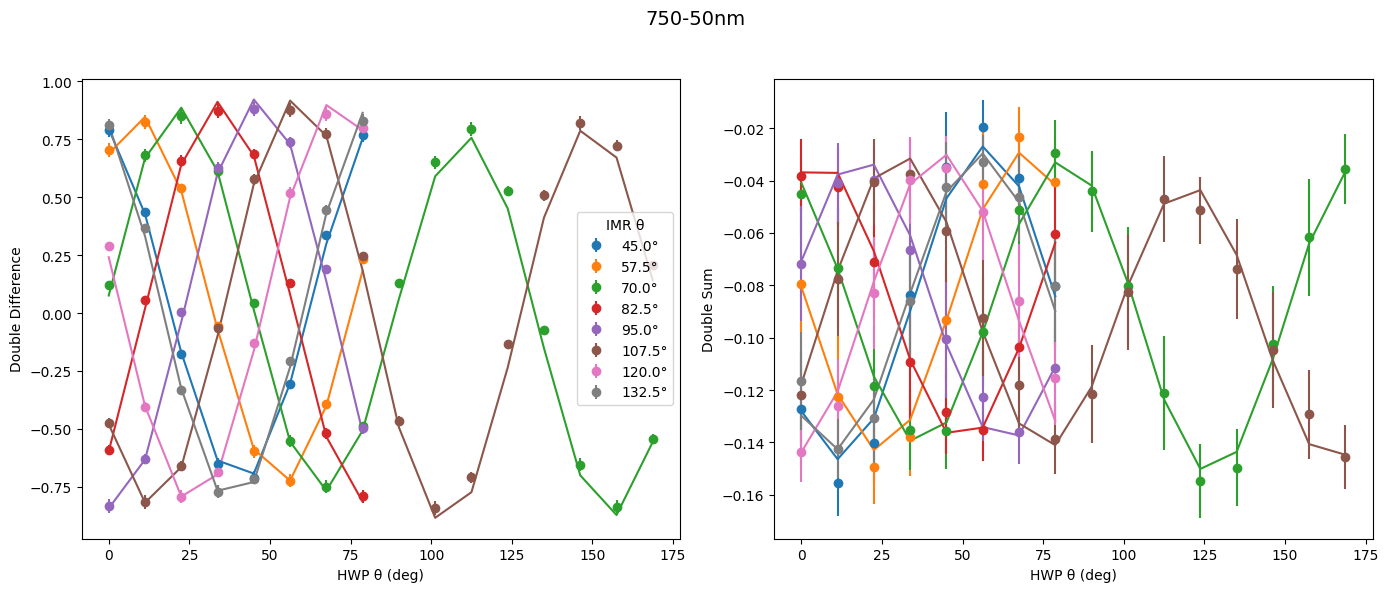

After p0: {'dichroic': {'phi': -0.40376578851120765, 'epsilon': 0.14027397491644722, 'theta': 25.032683243004854}, 'flc': {'phi': 3.6702923110761185, 'delta_theta': 4.999998626595743}, 'optics': {'phi': 0.8917471358111961, 'epsilon': 4.630000826418998e-09, 'theta': -17.23255828295043}, 'image_rotator': {'phi': 3.0668035138030163}, 'hwp': {'phi': 2.98832633565372, 'delta_theta': -2.433094653591122}, 'lp': {'theta': -5.0}}
Before p0: {'dichroic': {'phi': -0.40376578851120765, 'epsilon': 0.14027397491644722, 'theta': 25.032683243004854}, 'flc': {'phi': 3.6702923110761185, 'delta_theta': 4.999998626595743}, 'optics': {'phi': 0.8917471358111961, 'epsilon': 4.630000826418998e-09, 'theta': -17.23255828295043}, 'image_rotator': {'phi': 3.0668035138030163}, 'hwp': {'phi': 2.98832633565372, 'delta_theta': -2.433094653591122}, 'lp': {'theta': -5.0}}
Iteration #: 5
logl_value: 183.66031877832785
Best Fit Parameters: [-4.04021477e-01  1.40194053e-01  2.50184131e+01  3.67022221e+00
  4.99999992e+00 

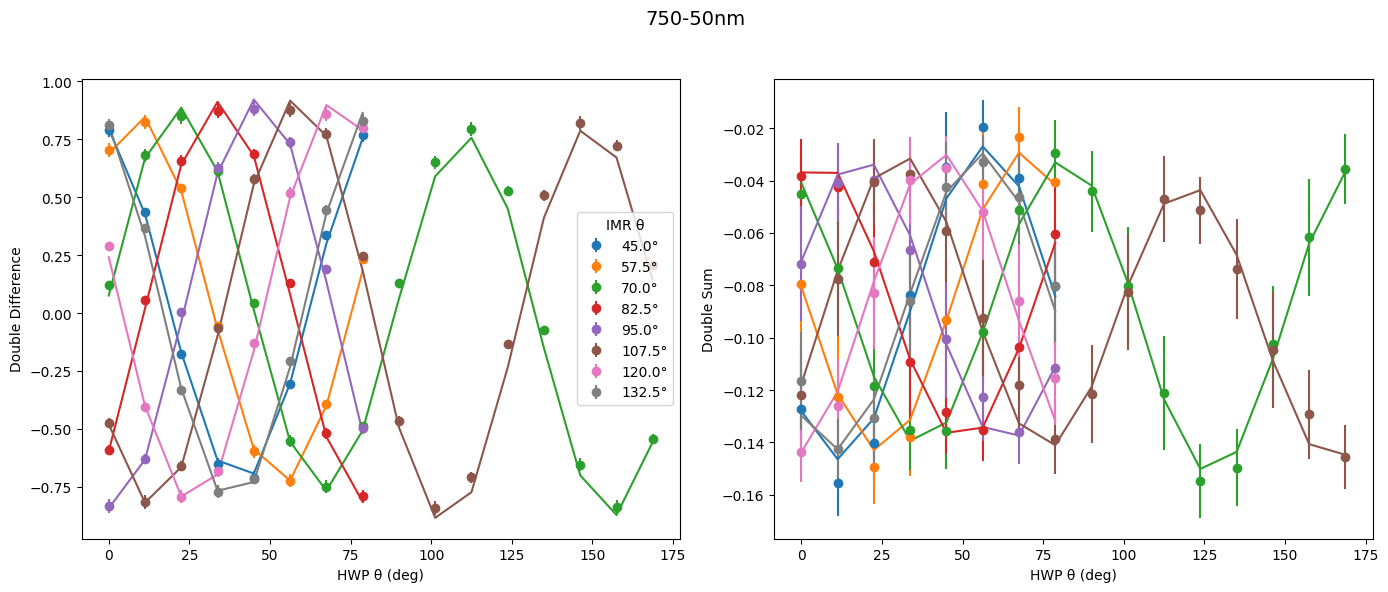

After p0: {'dichroic': {'phi': -0.4040214766091304, 'epsilon': 0.14019405301870136, 'theta': 25.018413100481485}, 'flc': {'phi': 3.6702222069986674, 'delta_theta': 4.999999924209418}, 'optics': {'phi': 0.8926182438805625, 'epsilon': 2.990687846943664e-11, 'theta': -17.19455291643197}, 'image_rotator': {'phi': 3.0668026233847945}, 'hwp': {'phi': 2.98834135690238, 'delta_theta': -2.4282150983902855}, 'lp': {'theta': -5.0}}
Before p0: {'dichroic': {'phi': -0.4040214766091304, 'epsilon': 0.14019405301870136, 'theta': 25.018413100481485}, 'flc': {'phi': 3.6702222069986674, 'delta_theta': 4.999999924209418}, 'optics': {'phi': 0.8926182438805625, 'epsilon': 2.990687846943664e-11, 'theta': -17.19455291643197}, 'image_rotator': {'phi': 3.0668026233847945}, 'hwp': {'phi': 2.98834135690238, 'delta_theta': -2.4282150983902855}, 'lp': {'theta': -5.0}}
Iteration #: 6
logl_value: 183.6603184644706
Best Fit Parameters: [-4.04003365e-01  1.40204171e-01  2.50199903e+01  3.67022780e+00
  4.99999999e+00  

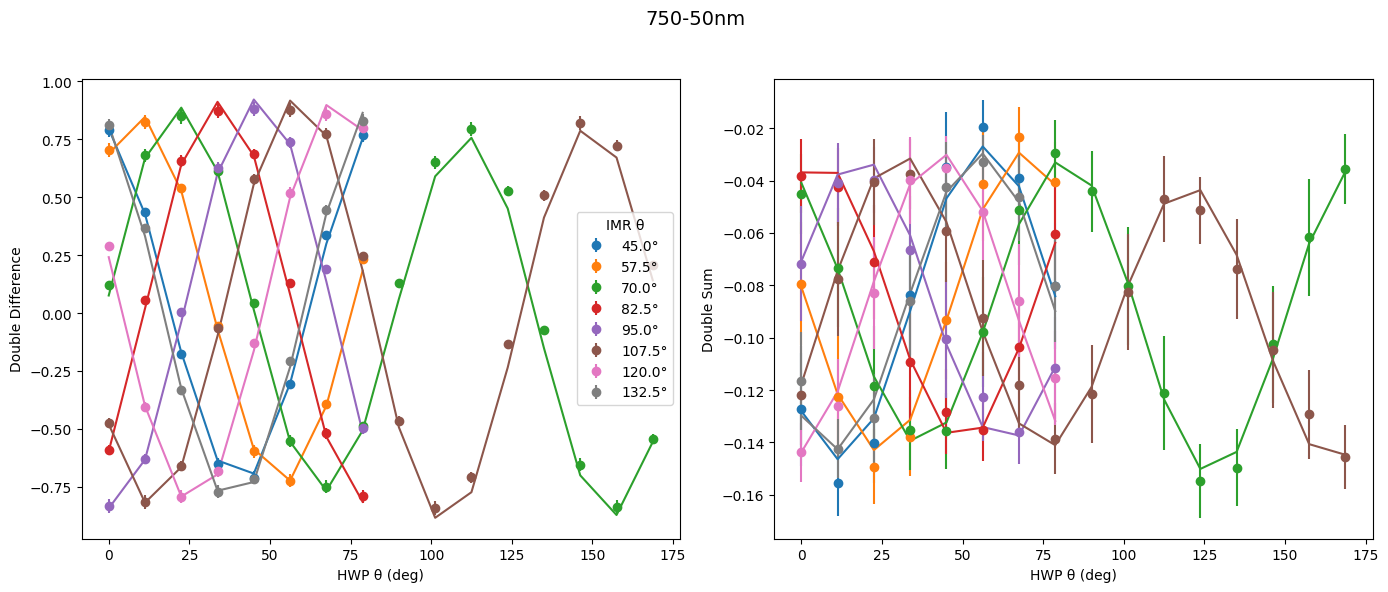

After p0: {'dichroic': {'phi': -0.40400336500714984, 'epsilon': 0.14020417069988933, 'theta': 25.01999033770109}, 'flc': {'phi': 3.670227803514347, 'delta_theta': 4.999999994793496}, 'optics': {'phi': 0.8925950761892398, 'epsilon': 2.9061433804327416e-11, 'theta': -17.195113143158405}, 'image_rotator': {'phi': 3.0668009760448185}, 'hwp': {'phi': 2.988339840445672, 'delta_theta': -2.4283970439276166}, 'lp': {'theta': -5.0}}
Before p0: {'dichroic': {'phi': -0.40400336500714984, 'epsilon': 0.14020417069988933, 'theta': 25.01999033770109}, 'flc': {'phi': 3.670227803514347, 'delta_theta': 4.999999994793496}, 'optics': {'phi': 0.8925950761892398, 'epsilon': 2.9061433804327416e-11, 'theta': -17.195113143158405}, 'image_rotator': {'phi': 3.0668009760448185}, 'hwp': {'phi': 2.988339840445672, 'delta_theta': -2.4283970439276166}, 'lp': {'theta': -5.0}}
Iteration #: 7
logl_value: 183.66031835504634
Best Fit Parameters: [-4.04018117e-01  1.40199179e-01  2.50191352e+01  3.67022763e+00
  4.99999999e

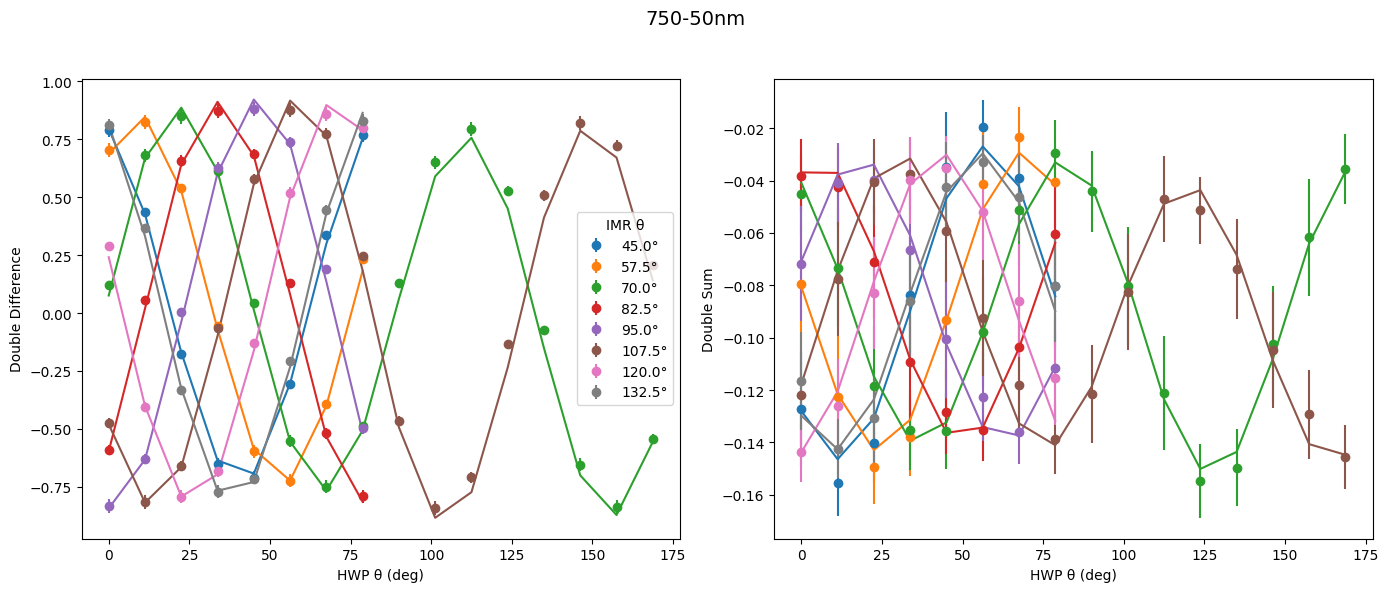

After p0: {'dichroic': {'phi': -0.404018116660139, 'epsilon': 0.14019917895483971, 'theta': 25.019135157776148}, 'flc': {'phi': 3.6702276281188118, 'delta_theta': 4.99999998994622}, 'optics': {'phi': 0.8926287311682051, 'epsilon': 6.653938611721304e-13, 'theta': -17.193743082497456}, 'image_rotator': {'phi': 3.0667998508219116}, 'hwp': {'phi': 2.988339918770342, 'delta_theta': -2.4282090826212324}, 'lp': {'theta': -5.0}}
Before p0: {'dichroic': {'phi': -0.404018116660139, 'epsilon': 0.14019917895483971, 'theta': 25.019135157776148}, 'flc': {'phi': 3.6702276281188118, 'delta_theta': 4.99999998994622}, 'optics': {'phi': 0.8926287311682051, 'epsilon': 6.653938611721304e-13, 'theta': -17.193743082497456}, 'image_rotator': {'phi': 3.0667998508219116}, 'hwp': {'phi': 2.988339918770342, 'delta_theta': -2.4282090826212324}, 'lp': {'theta': -5.0}}
Iteration #: 8
logl_value: 183.66031833727487
Best Fit Parameters: [-4.04022148e-01  1.40197216e-01  2.50188036e+01  3.67022647e+00
  5.00000000e+00 

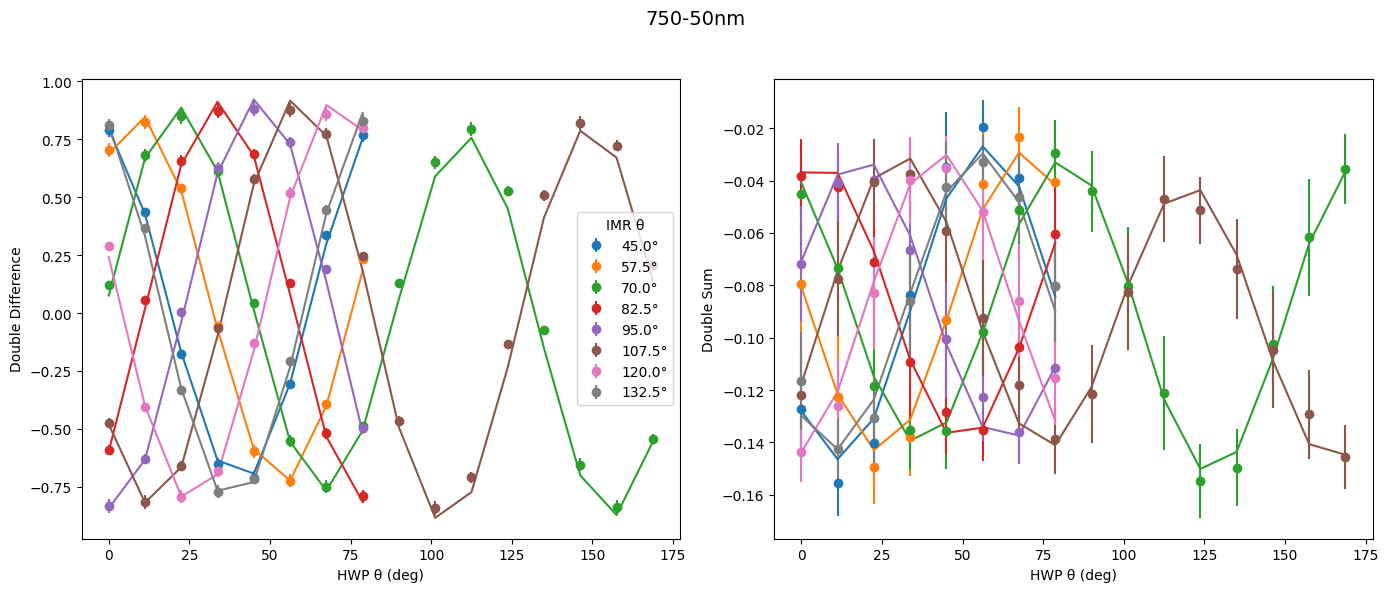

After p0: {'dichroic': {'phi': -0.40402214798486286, 'epsilon': 0.1401972160779963, 'theta': 25.018803565975333}, 'flc': {'phi': 3.670226472642412, 'delta_theta': 4.999999999473223}, 'optics': {'phi': 0.8926364506837958, 'epsilon': 5.691010260546786e-13, 'theta': -17.193441574471198}, 'image_rotator': {'phi': 3.0668001348653546}, 'hwp': {'phi': 2.988339716092262, 'delta_theta': -2.4281576698569802}, 'lp': {'theta': -5.0}}
Before p0: {'dichroic': {'phi': -0.40402214798486286, 'epsilon': 0.1401972160779963, 'theta': 25.018803565975333}, 'flc': {'phi': 3.670226472642412, 'delta_theta': 4.999999999473223}, 'optics': {'phi': 0.8926364506837958, 'epsilon': 5.691010260546786e-13, 'theta': -17.193441574471198}, 'image_rotator': {'phi': 3.0668001348653546}, 'hwp': {'phi': 2.988339716092262, 'delta_theta': -2.4281576698569802}, 'lp': {'theta': -5.0}}
Iteration #: 9
logl_value: 183.66031833604495
Best Fit Parameters: [-4.04023617e-01  1.40196470e-01  2.50186753e+01  3.67022607e+00
  5.00000000e+0

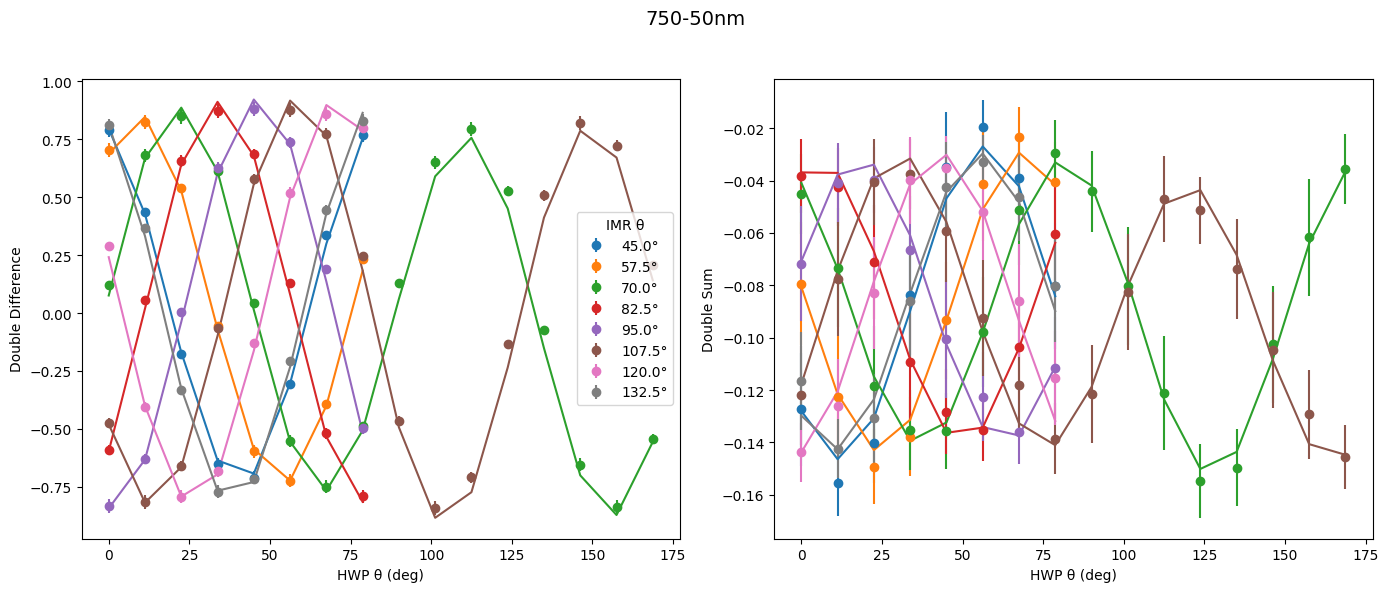

After p0: {'dichroic': {'phi': -0.40402361660975444, 'epsilon': 0.14019647042906408, 'theta': 25.018675324242466}, 'flc': {'phi': 3.670226065685379, 'delta_theta': 4.999999999216538}, 'optics': {'phi': 0.8926384252452386, 'epsilon': 5.743481291948801e-13, 'theta': -17.19339535787093}, 'image_rotator': {'phi': 3.0667999235482357}, 'hwp': {'phi': 2.9883399891635687, 'delta_theta': -2.4281408764132637}, 'lp': {'theta': -5.0}}
Before p0: {'dichroic': {'phi': -0.40402361660975444, 'epsilon': 0.14019647042906408, 'theta': 25.018675324242466}, 'flc': {'phi': 3.670226065685379, 'delta_theta': 4.999999999216538}, 'optics': {'phi': 0.8926384252452386, 'epsilon': 5.743481291948801e-13, 'theta': -17.19339535787093}, 'image_rotator': {'phi': 3.0667999235482357}, 'hwp': {'phi': 2.9883399891635687, 'delta_theta': -2.4281408764132637}, 'lp': {'theta': -5.0}}
Iteration #: 10
logl_value: 183.66031833508538
Best Fit Parameters: [-4.04024051e-01  1.40196388e-01  2.50186620e+01  3.67022623e+00
  5.00000000

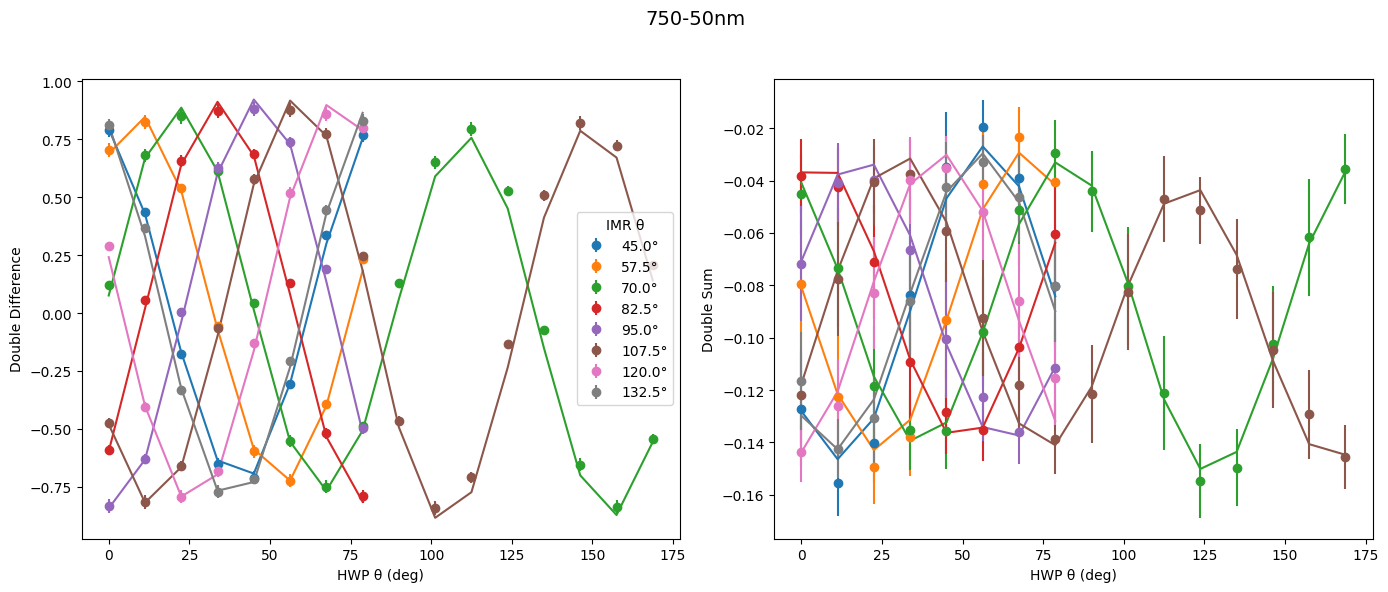

After p0: {'dichroic': {'phi': -0.4040240510423154, 'epsilon': 0.14019638768378476, 'theta': 25.018661998331694}, 'flc': {'phi': 3.67022623046398, 'delta_theta': 4.999999999559703}, 'optics': {'phi': 0.8926387988045232, 'epsilon': 5.839205810939875e-13, 'theta': -17.19338283567044}, 'image_rotator': {'phi': 3.066799685139225}, 'hwp': {'phi': 2.98834007194196, 'delta_theta': -2.4281384985836985}, 'lp': {'theta': -5.0}}
Before p0: {'dichroic': {'phi': -0.4040240510423154, 'epsilon': 0.14019638768378476, 'theta': 25.018661998331694}, 'flc': {'phi': 3.67022623046398, 'delta_theta': 4.999999999559703}, 'optics': {'phi': 0.8926387988045232, 'epsilon': 5.839205810939875e-13, 'theta': -17.19338283567044}, 'image_rotator': {'phi': 3.066799685139225}, 'hwp': {'phi': 2.98834007194196, 'delta_theta': -2.4281384985836985}, 'lp': {'theta': -5.0}}
Iteration #: 11
logl_value: 183.66031833478755
Best Fit Parameters: [-4.04024615e-01  1.40196181e-01  2.50186237e+01  3.67022632e+00
  5.00000000e+00  8.92

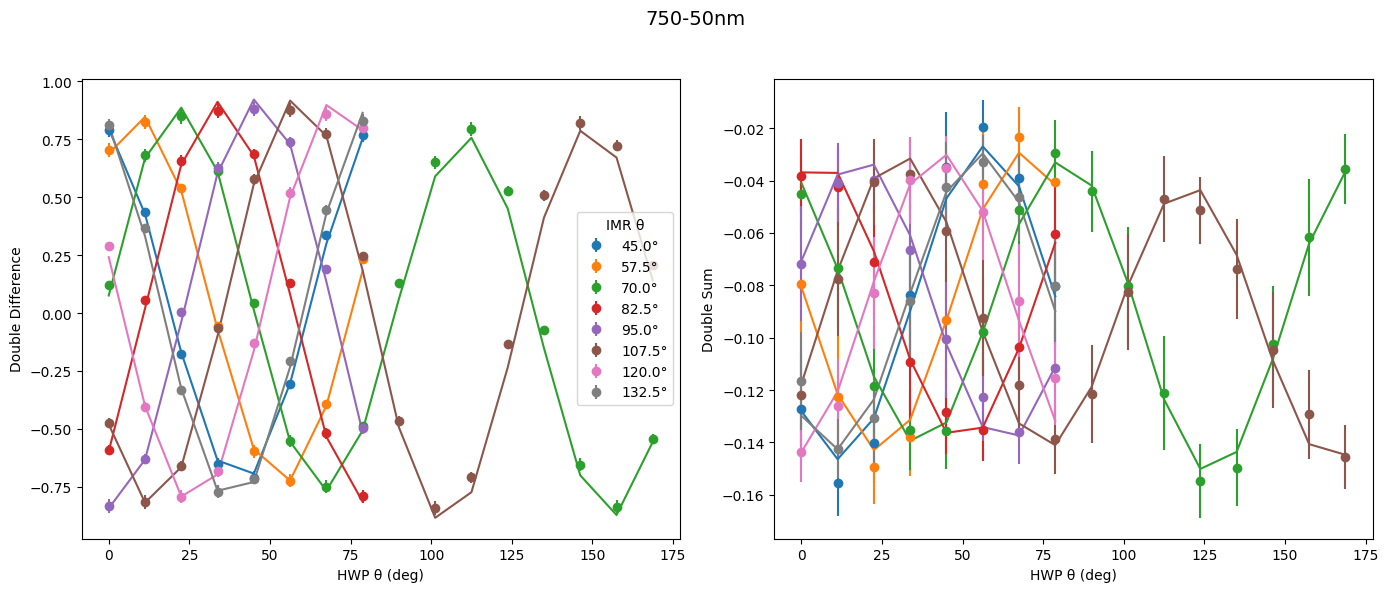

After p0: {'dichroic': {'phi': -0.40402461537991374, 'epsilon': 0.14019618075738208, 'theta': 25.018623692867298}, 'flc': {'phi': 3.6702263189902973, 'delta_theta': 4.999999999661837}, 'optics': {'phi': 0.8926397044380414, 'epsilon': 5.936530702929343e-13, 'theta': -17.193353168453555}, 'image_rotator': {'phi': 3.066799849860183}, 'hwp': {'phi': 2.9883400458970293, 'delta_theta': -2.428133763345417}, 'lp': {'theta': -5.0}}
Before p0: {'dichroic': {'phi': -0.40402461537991374, 'epsilon': 0.14019618075738208, 'theta': 25.018623692867298}, 'flc': {'phi': 3.6702263189902973, 'delta_theta': 4.999999999661837}, 'optics': {'phi': 0.8926397044380414, 'epsilon': 5.936530702929343e-13, 'theta': -17.193353168453555}, 'image_rotator': {'phi': 3.066799849860183}, 'hwp': {'phi': 2.9883400458970293, 'delta_theta': -2.428133763345417}, 'lp': {'theta': -5.0}}
Iteration #: 12
logl_value: 183.6603183345785
Best Fit Parameters: [-4.04023535e-01  1.40196741e-01  2.50187130e+01  3.67022628e+00
  5.00000000e

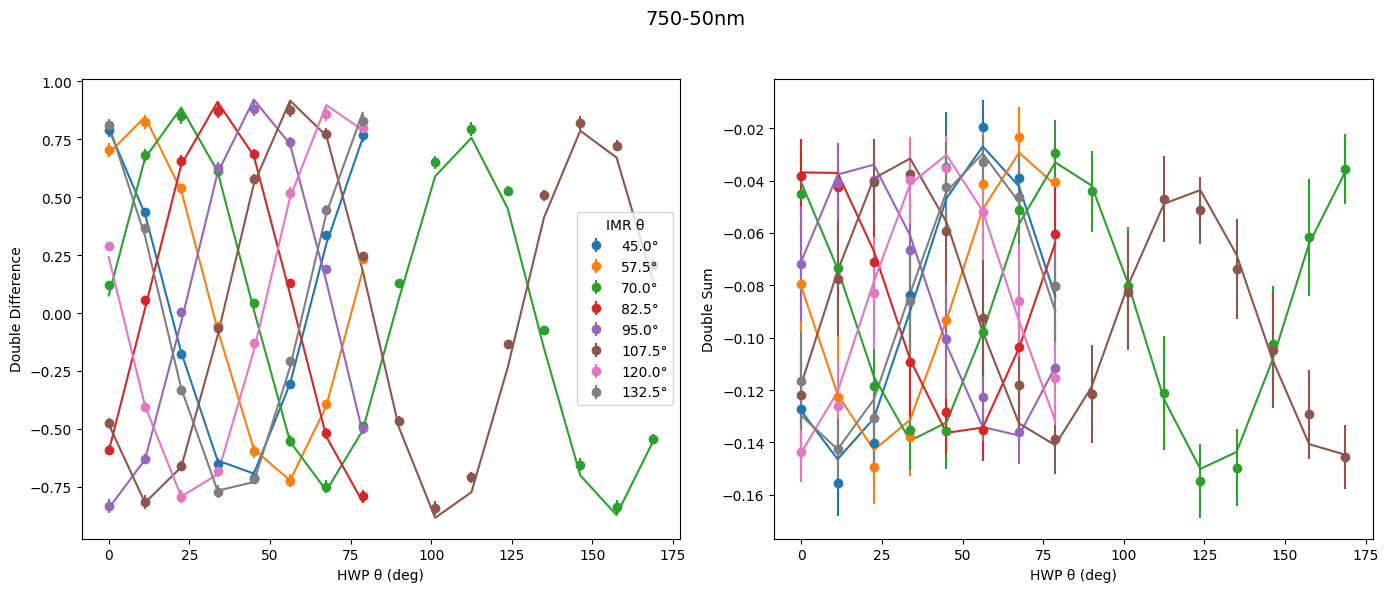

After p0: {'dichroic': {'phi': -0.4040235351895908, 'epsilon': 0.14019674097073492, 'theta': 25.01871302102132}, 'flc': {'phi': 3.6702262824592626, 'delta_theta': 4.999999999776886}, 'optics': {'phi': 0.8926390294348794, 'epsilon': 6.035467842878573e-13, 'theta': -17.1933566890572}, 'image_rotator': {'phi': 3.0667998131141854}, 'hwp': {'phi': 2.9883397947561496, 'delta_theta': -2.4281406522445756}, 'lp': {'theta': -5.0}}
Before p0: {'dichroic': {'phi': -0.4040235351895908, 'epsilon': 0.14019674097073492, 'theta': 25.01871302102132}, 'flc': {'phi': 3.6702262824592626, 'delta_theta': 4.999999999776886}, 'optics': {'phi': 0.8926390294348794, 'epsilon': 6.035467842878573e-13, 'theta': -17.1933566890572}, 'image_rotator': {'phi': 3.0667998131141854}, 'hwp': {'phi': 2.9883397947561496, 'delta_theta': -2.4281406522445756}, 'lp': {'theta': -5.0}}
Iteration #: 13
logl_value: 183.6603183345785
Best Fit Parameters: [-4.04023535e-01  1.40196741e-01  2.50187130e+01  3.67022628e+00
  5.00000000e+00 

In [7]:
# Unpolarized light for s_in as there is LP in the system already
s_in = np.array([1, 0, 0, 0])
bounds = [ 
    (-2 * np.pi, 2 * np.pi), # dichroic_retardance
    (0, 1), # dichroic_diattenuation
    (-90, 90), # dichroic_rotation_angle 
    (0.4 * 2 * np.pi, 0.6 * 2 * np.pi),  # delta_FLC
    (-5, 5),  # rot_FLC
    (-2 * np.pi, 2 * np.pi),  # delta_opts
    (0, 1),  # epsilon_opts
    (-90, 90),  # rot_opts
    (delta_derot - abs(delta_derot) * 0.1, delta_derot + abs(delta_derot) * 0.1),  # delta_derot
    (delta_HWP - abs(delta_HWP) * 0.1, delta_HWP + abs(delta_HWP) * 0.1),  # delta_HWP
    (-5, 5),  # offset_HWP
    (-5, 5),  # theta_pol
]
# Counters for iterative fitting
iteration = 1
previous_logl_value = np.inf
new_logl_value = None
best_result = None

while True:
    print("Before p0: " + str(p0))
    result, new_logl_value = inst.minimize_system_mueller_matrix(p0, system_mm, 
        interleaved_values, interleaved_stds, configuration_list, s_in = s_in,
        process_dataset = inst.process_dataset, 
        process_errors = inst.process_errors, 
        process_model = inst.process_model, bounds = bounds)
    new_logl_value = float(new_logl_value)
    
    # Print statements
    print("Iteration #: " + str(iteration))
    print("logl_value: " + str(new_logl_value))
    print("Best Fit Parameters: " + str(result.x))

    if new_logl_value >= previous_logl_value:
        print("Stopping: logl did not improve over the previous iteration.")
        if best_result is not None:
            result = best_result
        break

    previous_logl_value = new_logl_value
    best_result = result

    # Making a plot
    updated_system_mm = inst.update_system_mm(result.x, p0_keywords, system_mm)
    model = inst.model(result.x, p0_keywords, updated_system_mm, configuration_list, 
    process_model = inst.process_model)

    inst.plot_data_and_model(interleaved_values, interleaved_stds, model, 
        configuration_list, wavelength = wavelength_string)

    # Updating p0 for next time
    inst.update_p0(p0, result.x)
    print("After p0: " + str(p0))

    filename = f"/home/rebeccaz/Github/vampires_calibration/scipy_minimize/intermediate_data_files/{wavelength_string}_no_IMR_offset_fixed_EM_gain_iterate_on_any_improvement_ideal_start_table_phi_with_dichroic_best_fit_EM_gain_1.txt"
    with open(filename, 'w') as f:
        json.dump(p0, f, indent=4)

    iteration += 1

# Step 6: Plot model with best fit

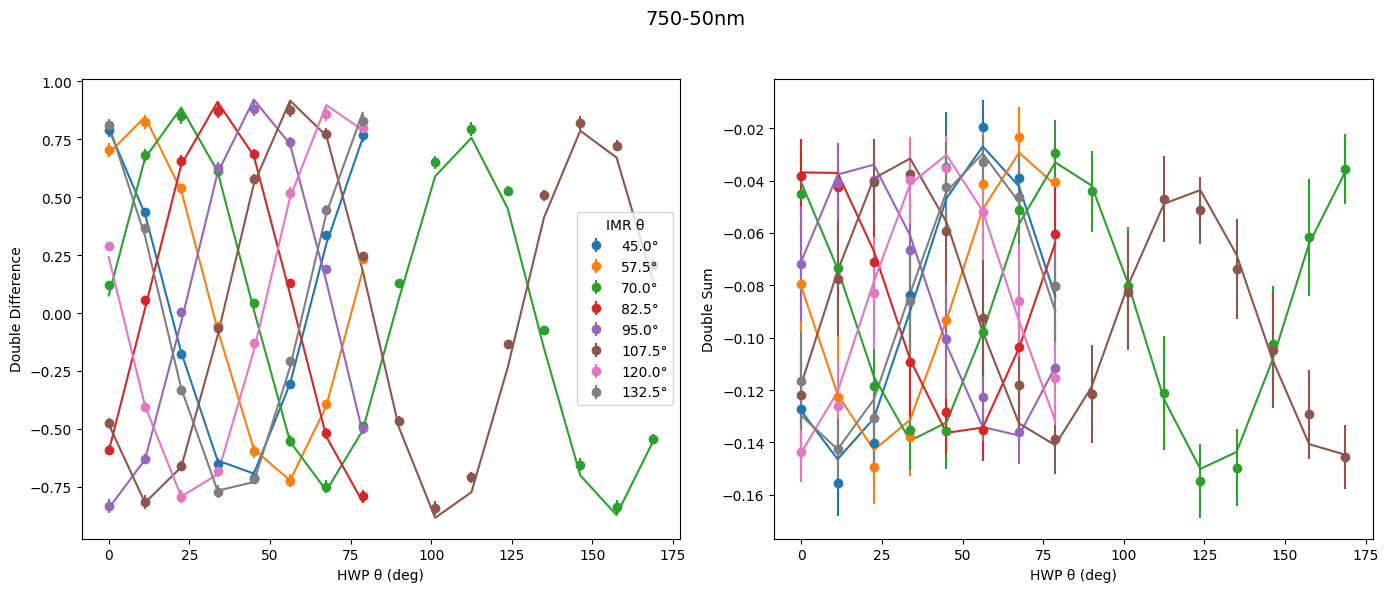

In [8]:
# Generate model with p0 keywords but scipy minimized results
# print(result.x)
# print(p0_keywords)

# Manually adjusting for a good fit
dichroic_phi = 0 # (waves)
dichroic_theta = 0 # (degrees)
# result.x = [2 * np.pi * dichroic_phi, dichroic_theta]

updated_system_mm = inst.update_system_mm(result.x, p0_keywords, system_mm)
model = inst.model(result.x, p0_keywords, system_mm, configuration_list, 
    process_model = inst.process_model)

inst.plot_data_and_model(interleaved_values, interleaved_stds, model, 
    configuration_list, wavelength = wavelength_string)